# 1. Load the Data
This section imports required libraries and loads the training dataset.

In [ ]:
# Import core libraries for data handling and visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Load the training data from CSV into a DataFrame
df = pd.read_csv("train.csv")

In [ ]:
# Preview the first five rows to inspect the dataset structure
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Check the number of rows and columns in the dataset
df.shape

(42000, 785)

# 2. Exploratory Data Analysis (EDA)
This section explores label distribution, sample images, and data quality.

label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64


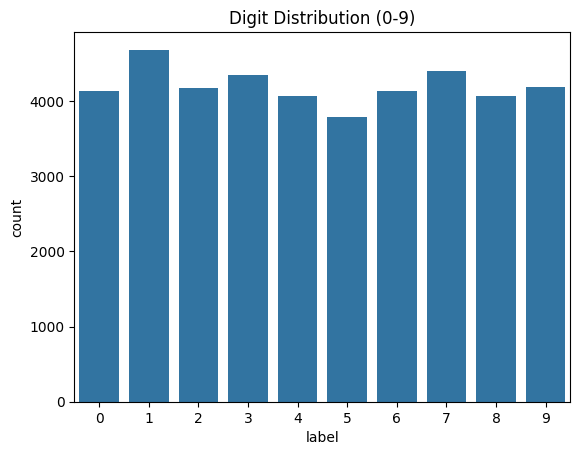

In [ ]:
# Display label counts and plot the digit class distribution
print(df["label"].value_counts().sort_index())

sns.countplot(x="label", data=df)
plt.title("Digit Distribution (0-9)")
plt.show()

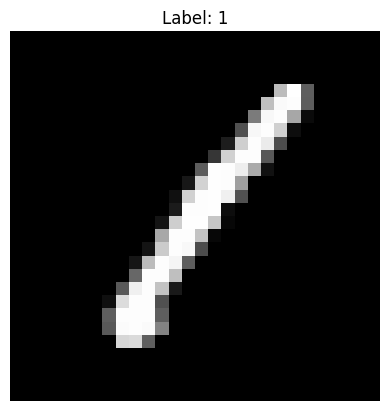

In [ ]:
# Separate features/labels and visualize one sample digit image
# Separate label and pixels
X = df.drop("label", axis=1).values   # pixel values
y = df["label"].values                 # digit labels

# Reshape one row from 784 numbers -> 28x28 grid
sample_image = X[0].reshape(28, 28)

plt.imshow(sample_image, cmap="gray")
plt.title(f"Label: {y[0]}")
plt.axis("off")
plt.show()

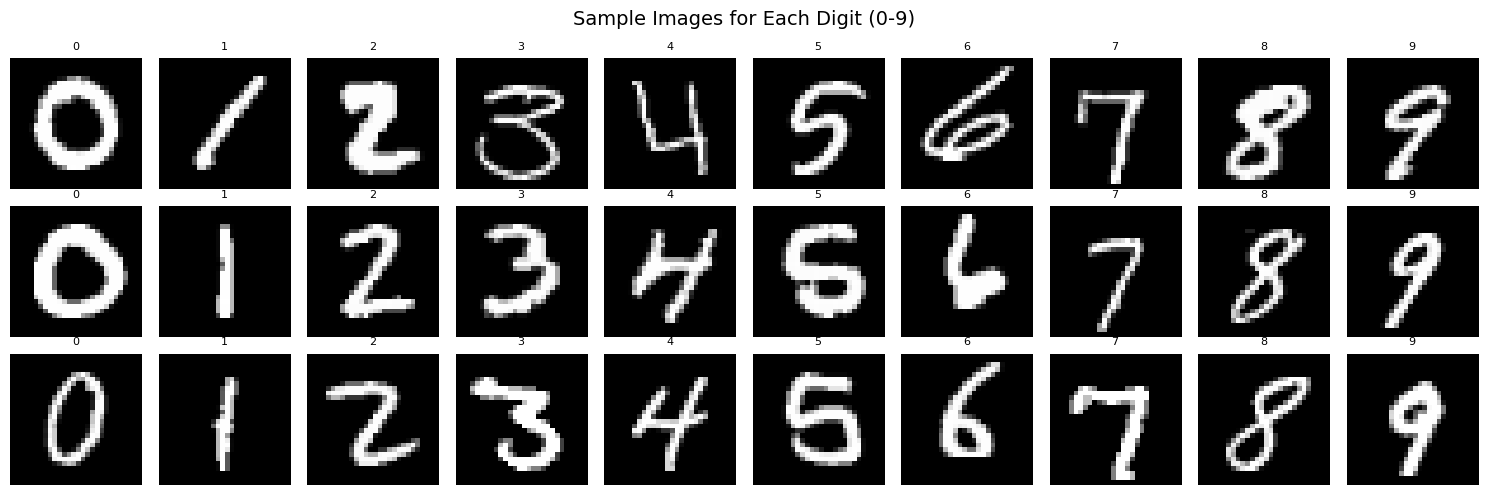

In [ ]:
# Plot a few sample images for each digit class (0-9)
fig, axes = plt.subplots(3, 10, figsize=(15, 5))

for digit in range(10):
    # find first 3 examples of each digit
    indices = np.where(y == digit)[0][:3]
    for row, idx in enumerate(indices):
        axes[row, digit].imshow(X[idx].reshape(28, 28), cmap="gray")
        axes[row, digit].axis("off")
        axes[row, digit].set_title(f"{digit}", fontsize=8)

plt.suptitle("Sample Images for Each Digit (0-9)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Print summary statistics for pixel intensity values
print("Min pixel value:", X.min())
print("Max pixel value:", X.max())
print("Mean pixel value:", X.mean().round(2))

Min pixel value: 0
Max pixel value: 255
Mean pixel value: 33.41


In [ ]:
# Verify whether the dataset contains any missing values
print("Missing values:", df.isnull().sum().sum())

Missing values: 0


# 3. Preprocessing
This section normalizes features and creates train/test splits.

In [ ]:
# Split features/target and normalize pixel values to the 0-1 range
# Split features and target
X = df.drop("label", axis=1).values
y = df["label"].values

# Normalize: 0-255 -> 0-1
X = X / 255.0

print("Min pixel after normalization:", X.min())
print("Max pixel after normalization:", X.max())
print("Sample pixel values:", X[0][:10].round(3))

Min pixel after normalization: 0.0
Max pixel after normalization: 1.0
Sample pixel values: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
# Create training and testing sets for model evaluation
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Train size: (33600, 784)
Test size:  (8400, 784)


# 4. Model Training
This section trains baseline and neural-network models, then compares performance.

In [ ]:
# Train a Random Forest baseline model and report test accuracy
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_acc*100:.2f}%")

Random Forest Accuracy: 96.30%


In [ ]:
# Build a feed-forward neural network architecture for digit classification
import tensorflow as tf
from tensorflow import keras

# Build the model
model = keras.Sequential([
    keras.layers.Dense(256, activation="relu", input_shape=(784,)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10,  activation="softmax")  # 10 outputs = 10 digits
])

model.summary()

c:\Users\saras\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile and train the neural network while tracking validation accuracy
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
945/945 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9190 - loss: 0.2759 - val_accuracy: 0.9613 - val_loss: 0.1348
Epoch 2/10
945/945 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9660 - loss: 0.1097 - val_accuracy: 0.9705 - val_loss: 0.1025
Epoch 3/10
945/945 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9767 - loss: 0.0702 - val_accuracy: 0.9735 - val_loss: 0.1007
Epoch 4/10
945/945 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9831 - loss: 0.0506 - val_accuracy: 0.9693 - val_loss: 0.1095
Epoch 5/10
945/945 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9875 - loss: 0.0392 - val_accuracy: 0.9667 - val_loss: 0.1188
Epoch 6/10
945/945 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9890 - loss: 0.0315 - val_accuracy: 0.9702 - val_loss: 0.1130
Epoch 7/10
945/945 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9922 - loss: 0.0234 - val_accuracy: 0.9729 - val_loss: 0.0986
Epoch 8/10
945/945 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9925 - loss: 0.0239 - val_accuracy: 0.

In [ ]:
# Evaluate neural-network performance and compare it with Random Forest
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Neural Network Accuracy: {test_acc*100:.2f}%")
print(f"Random Forest Accuracy:  {rf_acc*100:.2f}%")

Neural Network Accuracy: 96.74%
Random Forest Accuracy:  96.30%


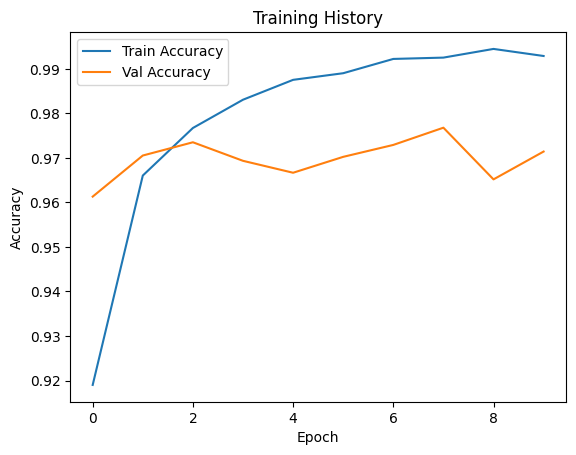

In [ ]:
# Plot training and validation accuracy across epochs
plt.plot(history.history["accuracy"],     label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Training History")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# 5. Visualize Predictions
This section analyzes prediction quality with confusion matrix and sample outcomes.

263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


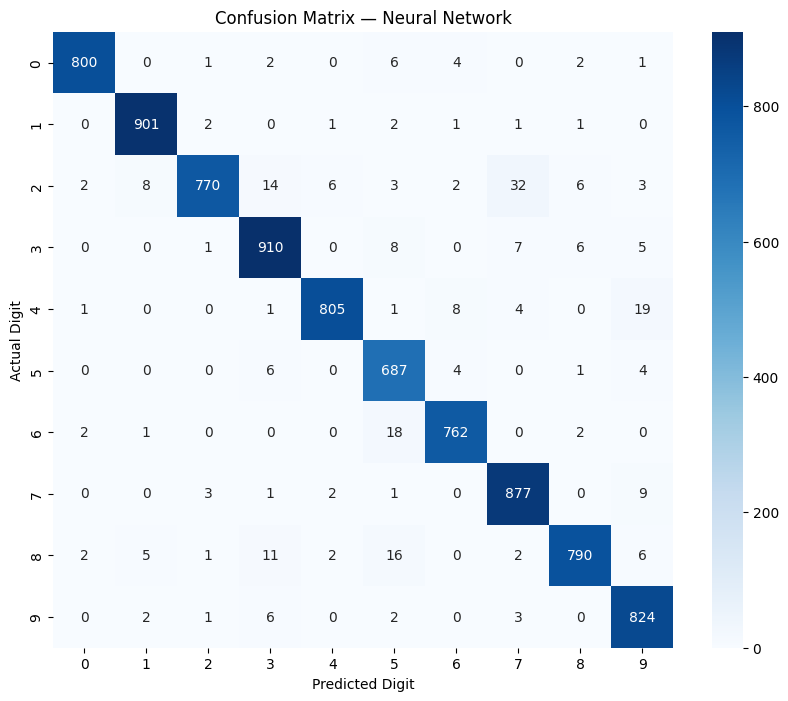

In [ ]:
# Build and display a confusion matrix for neural-network predictions
from sklearn.metrics import confusion_matrix

nn_pred = model.predict(X_test).argmax(axis=1)

cm = confusion_matrix(y_test, nn_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Neural Network")
plt.ylabel("Actual Digit")
plt.xlabel("Predicted Digit")
plt.show()

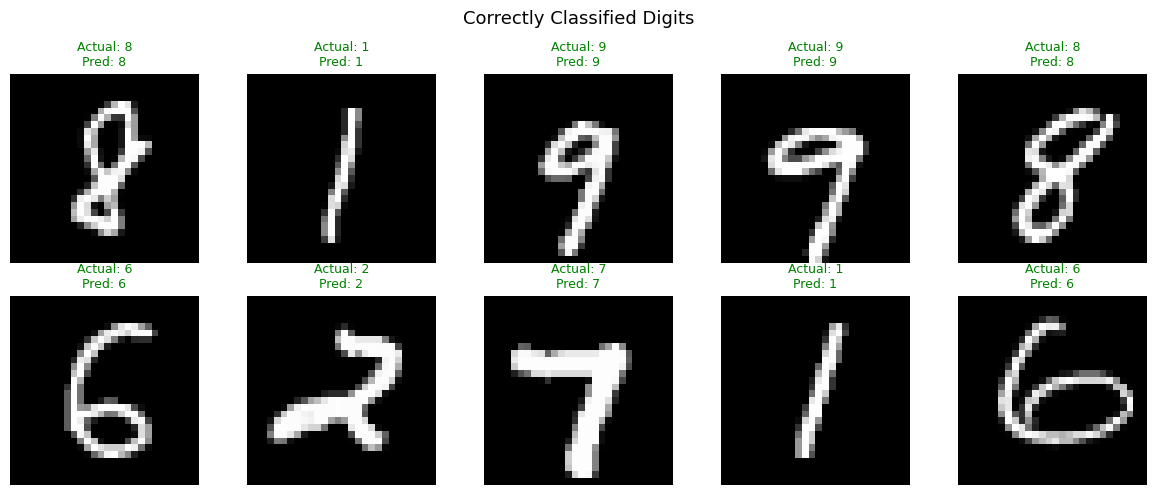

In [ ]:
# Visualize correctly classified test samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

correct = np.where(nn_pred == y_test)[0][:10]

for i, idx in enumerate(correct):
    axes[i].imshow(X_test[idx].reshape(28, 28), cmap="gray")
    axes[i].set_title(f"Actual: {y_test[idx]}\nPred: {nn_pred[idx]}", 
                       fontsize=9, color="green")
    axes[i].axis("off")

plt.suptitle("Correctly Classified Digits", fontsize=13)
plt.tight_layout()
plt.show()

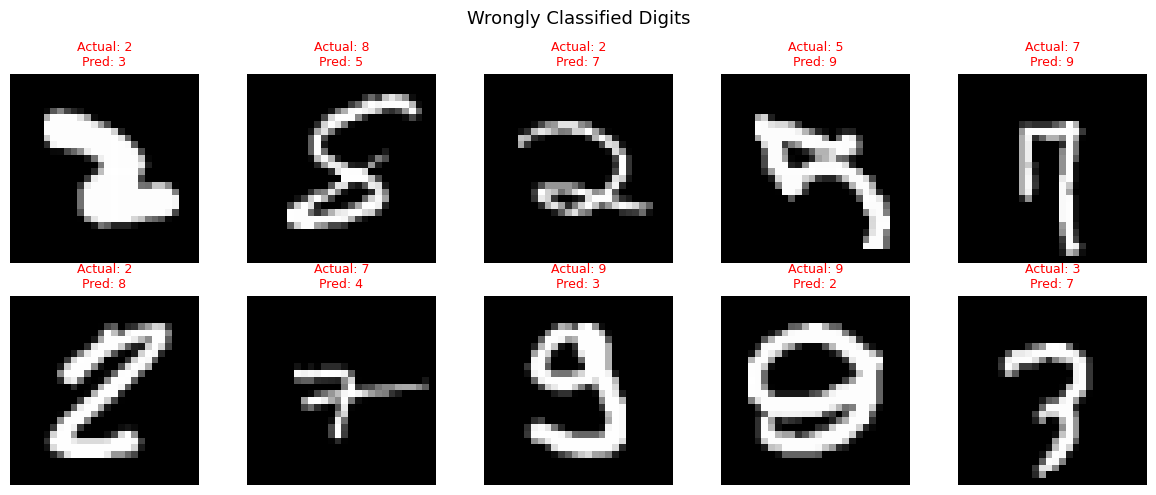

In [ ]:
# Visualize misclassified test samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

wrong = np.where(nn_pred != y_test)[0][:10]

for i, idx in enumerate(wrong):
    axes[i].imshow(X_test[idx].reshape(28, 28), cmap="gray")
    axes[i].set_title(f"Actual: {y_test[idx]}\nPred: {nn_pred[idx]}", 
                       fontsize=9, color="red")
    axes[i].axis("off")

plt.suptitle("Wrongly Classified Digits", fontsize=13)
plt.tight_layout()
plt.show()

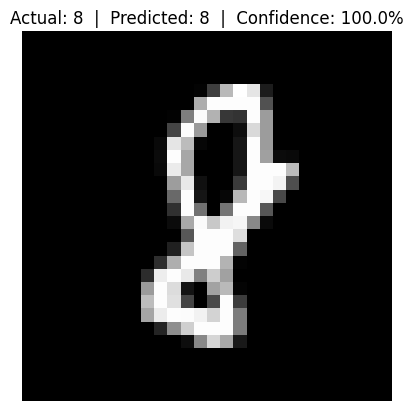

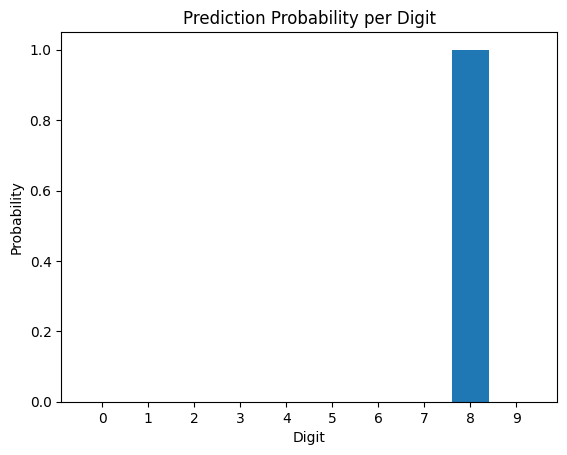

In [ ]:
# Define a helper to inspect one sample prediction and its class probabilities
def predict_digit(index):
    image  = X_test[index]
    actual = y_test[index]

    # Get probabilities for all 10 digits
    probs  = model.predict(image.reshape(1, 784), verbose=0)[0]
    pred   = probs.argmax()

    # Show image
    plt.imshow(image.reshape(28, 28), cmap="gray")
    plt.title(f"Actual: {actual}  |  Predicted: {pred}  |  Confidence: {probs[pred]*100:.1f}%")
    plt.axis("off")
    plt.show()

    # Show probability for each digit
    plt.bar(range(10), probs)
    plt.xticks(range(10))
    plt.title("Prediction Probability per Digit")
    plt.xlabel("Digit")
    plt.ylabel("Probability")
    plt.show()

predict_digit(0)